# 02 — Stuff Decomposition (H3 velocity, H4 splitter)

Implements `s1_design_spec.md`. Results only — interpretation belongs to the project owner.
NPB reference band (qualitative): four-seam average 98–99 mph.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path("../data/raw")
FIG = Path("../figures")
B = 10_000
rng = np.random.default_rng(7)
pd.set_option("display.width", 200)

WHIFF = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
SWING = WHIFF | {"foul", "foul_tip", "foul_bunt", "bunt_foul_tip", "hit_into_play"}
NPB_LOW = 98.0

## Load and assign contexts
Spring training and 2026 postseason excluded. Context = season × role (start = appearance beginning in the 1st inning).

In [2]:
def load(name, seasons):
    d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
                   for y in seasons], ignore_index=True)
    d = d[d.game_type != "S"]
    d = d[~((d.season == 2026) & d.game_type.isin(["F", "D", "L", "W"]))]
    d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
    d = d[~d.pa_id.isin(d.loc[d.events == "intent_walk", "pa_id"])]
    d = d[(d.description != "pitchout") & d.pitch_type.notna() & d.release_speed.notna() & d.plate_x.notna()].copy()
    first = d.groupby("game_pk").inning.transform("min")
    d["role"] = np.where(first == 1, "start", "relief")
    d["context"] = d.season.astype(str) + " " + d.role
    d["ivb"] = d.pfx_z * 12
    d["hb"] = d.pfx_x * 12
    d["swing"] = d.description.isin(SWING)
    d["whiff"] = d.description.isin(WHIFF)
    d["ooz"] = d.zone >= 11
    d["pitcher_name"] = name
    return d

sas = load("sasaki", [2025, 2026])
yam = load("yamamoto", [2024, 2025, 2026])
yam = yam[yam.role == "start"]
pitches = pd.concat([sas, yam], ignore_index=True)
pd.crosstab([pitches.pitcher_name, pitches.context], pitches.pitch_type)

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:6:

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_14143/236919391.py:6:

pitch_type                 CU   FC    FF   FO   FS   SI   SL   ST
pitcher_name context                                             
sasaki       2025 relief    0    0    95   90    0    6    0    0
             2025 start     0    0   299  196    0    0    0  101
             2026 relief    0    0    21    0   15    0   12    0
             2026 start     0    0   860  152  598    0  442    0
yamamoto     2024 start   395  111   724    0  399   42   77    3
             2025 start   604  369  1123    0  840  253   91    1
             2026 start   360  406   715    0  728  358  166    0

## Hitter tiers (same rules as H1) for effectiveness metrics

In [3]:
tiers = []
for y in [2024, 2025, 2026]:
    x = pd.read_csv(RAW / f"batter_xwoba_{y}.csv")
    lg = (x.est_woba * x.pa).sum() / x.pa.sum()
    x["adj"] = (x.pa * x.est_woba + 100 * lg) / (x.pa + 100)
    s = x.sort_values("adj")
    med = s.adj[(s.pa.cumsum() / s.pa.sum()) >= 0.5].iloc[0]
    x["tier"] = np.where(x.adj >= med, "High", "Low")
    tiers.append(x[["player_id", "tier"]].assign(season=y))
pitches = pitches.merge(pd.concat(tiers), left_on=["batter", "season"], right_on=["player_id", "season"], how="left")
print("Pitches with no tier:", pitches.tier.isna().sum())

Pitches with no tier: 0


## Bootstrap helpers (cluster by game)

In [4]:
def boot_mean(df, col):
    """Pitch-weighted mean of `col`, CI from resampling games."""
    g = df.groupby("game_pk")[col].agg(["sum", "size"])
    w = rng.multinomial(len(g), np.full(len(g), 1 / len(g)), size=B)
    draws = (w @ g["sum"].values) / (w @ g["size"].values)
    return g["sum"].sum() / g["size"].sum(), draws

def boot_rate(df, num_mask, den_mask):
    """Tier-standardized rate (%), CI from resampling games."""
    games = np.sort(df.game_pk.unique())
    w = np.vstack([np.ones(len(games)), rng.multinomial(len(games), np.full(len(games), 1 / len(games)), size=B)])
    per_tier, ns = [], []
    for tier in ["Low", "High"]:
        sub = df[den_mask & (df.tier == tier)]
        num = sub[num_mask[sub.index]].groupby("game_pk").size().reindex(games, fill_value=0).values
        den = sub.groupby("game_pk").size().reindex(games, fill_value=0).values
        with np.errstate(invalid="ignore", divide="ignore"):
            per_tier.append(100 * (w @ num) / (w @ den))
        ns.append(int(den.sum()))
    r = (per_tier[0] + per_tier[1]) / 2
    return r[0], r[1:], ns

def ci(draws):
    draws = draws[~np.isnan(draws)]
    if len(draws) == 0:  # a tier had no pitches in this cell
        return np.nan, np.nan
    return np.percentile(draws, 2.5), np.percentile(draws, 97.5)

## Physical profile by pitcher × context × pitch type

In [5]:
KEY = ["FF", "FO", "FS"]
rows, DRAWS = [], {}
for (p, c, pt), d in pitches[pitches.pitch_type.isin(KEY)].groupby(["pitcher_name", "context", "pitch_type"]):
    if p == "yamamoto" and pt != "FF" and pt != "FS":
        continue
    row = {"pitcher": p, "context": c, "pitch": pt, "n": len(d), "games": d.game_pk.nunique()}
    for col in ["release_speed", "release_spin_rate", "ivb", "hb"]:
        est, draws = boot_mean(d.dropna(subset=[col]), col)
        lo, hi = ci(draws)
        row[col] = f"{est:.1f} [{lo:.1f}, {hi:.1f}]"
        DRAWS[(p, c, pt, col)] = (est, draws)
    rows.append(row)
physical = pd.DataFrame(rows).rename(columns={"release_speed": "velo", "release_spin_rate": "spin", "ivb": "IVB (in)", "hb": "HB (in)"})
physical.to_csv("../data/processed/s1_physical.csv", index=False)
physical

,pitcher,context,pitch,n,games,velo,spin,IVB (in),HB (in)
0,sasaki,2025 relief,FF,95,11,"98.9 [98.5, 99.5]","2158.2 [2118.8, 2190.0]","14.9 [14.6, 15.2]","-9.8 [-10.6, -8.7]"
1,sasaki,2025 relief,FO,90,11,"86.4 [85.6, 87.3]","569.1 [539.8, 602.7]","-4.3 [-5.3, -3.3]","-4.6 [-5.1, -3.9]"
2,sasaki,2025 start,FF,299,8,"96.0 [95.3, 96.8]","2080.2 [2062.9, 2098.3]","14.3 [14.0, 14.6]","-10.6 [-11.1, -10.1]"
3,sasaki,2025 start,FO,196,8,"84.8 [84.2, 85.4]","482.6 [466.1, 500.3]","-3.9 [-4.6, -3.1]","-0.8 [-1.7, 0.0]"
4,sasaki,2026 relief,FF,21,3,"99.2 [98.7, 100.0]","2417.4 [2372.3, 2476.7]","15.5 [14.8, 16.3]","-11.1 [-13.4, -9.2]"
5,sasaki,2026 relief,FS,15,3,"91.7 [90.5, 92.2]","1159.1 [1106.5, 1178.6]","-1.2 [-1.8, -0.5]","-8.2 [-10.5, -2.8]"
6,sasaki,2026 start,FF,860,23,"97.8 [97.4, 98.2]","2279.3 [2234.8, 2319.4]","16.1 [15.6, 16.5]","-9.7 [-10.2, -9.2]"
7,sasaki,2026 start,FO,152,16,"85.3 [84.9, 85.9]","603.3 [575.9, 659.5]","-2.7 [-3.4, -1.3]","-3.2 [-4.6, -2.0]"
8,sasaki,2026 start,FS,598,19,"90.2 [89.9, 90.5]","909.5 [877.4, 945.2]","1.2 [0.8, 1.6]","-7.1 [-7.9, -6.2]"
9,yamamoto,2024 start,FF,724,22,"95.6 [95.3, 95.8]","2172.6 [2149.0, 2197.7]","15.7 [15.3, 16.1]","-7.2 [-7.6, -6.8]"


## H3 — Four-seam velocity vs. NPB band, plus per-game 90th percentile

In [6]:
ff = pitches[(pitches.pitch_type == "FF")]
p90 = ff.groupby(["pitcher_name", "context", "game_pk"]).release_speed.quantile(0.9).groupby(["pitcher_name", "context"]).mean()
h3 = []
for (p, c), v in p90.items():
    est, draws = DRAWS[(p, c, "FF", "release_speed")]
    lo, hi = ci(draws)
    h3.append({"pitcher": p, "context": c, "FF avg": round(est, 1), "ci": f"[{lo:.1f}, {hi:.1f}]",
               "avg per-game p90": round(v, 1), "vs NPB low (98.0)": round(est - NPB_LOW, 1),
               "below NPB band (<= 97.0)": "YES" if est <= NPB_LOW - 1 else "no"})
pd.DataFrame(h3)

,pitcher,context,FF avg,ci,avg per-game p90,vs NPB low (98.0),below NPB band (<= 97.0)
0,sasaki,2025 relief,98.9,"[98.5, 99.5]",99.7,0.9,no
1,sasaki,2025 start,96.0,"[95.3, 96.8]",97.1,-2.0,YES
2,sasaki,2026 relief,99.2,"[98.7, 100.0]",100.1,1.2,no
3,sasaki,2026 start,97.8,"[97.4, 98.2]",98.9,-0.2,no
4,yamamoto,2024 start,95.6,"[95.3, 95.8]",96.4,-2.4,YES
5,yamamoto,2025 start,95.5,"[95.3, 95.7]",96.4,-2.5,YES
6,yamamoto,2026 start,96.1,"[95.8, 96.3]",96.9,-1.9,YES


## FF − splitter velocity gap

In [7]:
rows = []
for c in ["2025 start", "2025 relief", "2026 start", "2026 relief"]:
    for spl in ["FO", "FS"]:
        if ("sasaki", c, spl, "release_speed") not in DRAWS:
            continue
        f_est, f_d = DRAWS[("sasaki", c, "FF", "release_speed")]
        s_est, s_d = DRAWS[("sasaki", c, spl, "release_speed")]
        lo, hi = ci(f_d - s_d)
        rows.append({"pitcher": "sasaki", "context": c, "splitter": spl, "gap mph": round(f_est - s_est, 1), "ci": f"[{lo:.1f}, {hi:.1f}]"})
for c in ["2024 start", "2025 start", "2026 start"]:
    f_est, f_d = DRAWS[("yamamoto", c, "FF", "release_speed")]
    s_est, s_d = DRAWS[("yamamoto", c, "FS", "release_speed")]
    lo, hi = ci(f_d - s_d)
    rows.append({"pitcher": "yamamoto", "context": c, "splitter": "FS", "gap mph": round(f_est - s_est, 1), "ci": f"[{lo:.1f}, {hi:.1f}]"})
gaps = pd.DataFrame(rows)
gaps

,pitcher,context,splitter,gap mph,ci
0,sasaki,2025 start,FO,11.2,"[10.3, 12.2]"
1,sasaki,2025 relief,FO,12.6,"[11.5, 13.6]"
2,sasaki,2026 start,FO,12.5,"[11.8, 13.1]"
3,sasaki,2026 start,FS,7.6,"[7.2, 8.1]"
4,sasaki,2026 relief,FS,7.6,"[6.7, 8.7]"
5,yamamoto,2024 start,FS,5.2,"[4.7, 5.6]"
6,yamamoto,2025 start,FS,4.4,"[4.0, 4.8]"
7,yamamoto,2026 start,FS,4.6,"[4.3, 4.9]"


## Effectiveness by pitch type (tier-standardized whiff per swing and chase rate)

In [8]:
rows, EFF = [], {}
for (p, c, pt), d in pitches[pitches.pitch_type.isin(KEY)].groupby(["pitcher_name", "context", "pitch_type"]):
    if p == "yamamoto" and pt not in ("FF", "FS"):
        continue
    w_est, w_d, w_n = boot_rate(d, d.whiff, d.swing)
    c_est, c_d, c_n = boot_rate(d, d.swing, d.ooz)
    EFF[(p, c, pt, "whiff")], EFF[(p, c, pt, "chase")] = (w_est, w_d), (c_est, c_d)
    rows.append({"pitcher": p, "context": c, "pitch": pt,
                 "whiff/swing": f"{w_est:.1f} [{ci(w_d)[0]:.1f}, {ci(w_d)[1]:.1f}]", "swings (low/high)": w_n,
                 "chase": f"{c_est:.1f} [{ci(c_d)[0]:.1f}, {ci(c_d)[1]:.1f}]", "ooz pitches (low/high)": c_n,
                 "low_n": "LOW N" if min(w_n + c_n) < 30 else ""})
eff = pd.DataFrame(rows)
eff.to_csv("../data/processed/s1_effectiveness.csv", index=False)
eff

,pitcher,context,pitch,whiff/swing,swings (low/high),chase,ooz pitches (low/high),low_n
0,sasaki,2025 relief,FF,"15.4 [7.2, 21.2]","[29, 22]","29.6 [17.4, 50.3]","[19, 15]",LOW N
1,sasaki,2025 relief,FO,"52.9 [42.7, 70.1]","[15, 24]","38.5 [26.2, 48.8]","[27, 40]",LOW N
2,sasaki,2025 start,FF,"9.0 [4.6, 13.1]","[66, 82]","19.0 [8.5, 23.7]","[37, 73]",
3,sasaki,2025 start,FO,"33.6 [23.4, 45.9]","[27, 53]","27.0 [16.8, 36.2]","[53, 80]",LOW N
4,sasaki,2026 relief,FF,"12.5 [4.5, 50.0]","[8, 6]","50.0 [33.3, 58.3]","[6, 3]",LOW N
5,sasaki,2026 relief,FS,"nan [nan, nan]","[4, 0]","18.8 [11.1, 33.3]","[8, 3]",LOW N
6,sasaki,2026 start,FF,"16.2 [12.0, 20.5]","[196, 236]","28.1 [23.8, 32.3]","[168, 209]",
7,sasaki,2026 start,FO,"30.2 [13.1, 39.0]","[31, 36]","25.0 [18.2, 32.7]","[46, 50]",
8,sasaki,2026 start,FS,"34.0 [27.4, 40.4]","[137, 193]","40.2 [35.9, 44.4]","[151, 216]",
9,yamamoto,2024 start,FF,"15.4 [10.3, 20.6]","[175, 169]","21.5 [16.9, 26.5]","[128, 158]",


## Delivery: arm angle, release point, extension, and per-game release consistency (FF)

In [9]:
rows = []
for (p, c), d in ff.groupby(["pitcher_name", "context"]):
    sd = d.groupby("game_pk")[["release_pos_x", "release_pos_z"]].std().mean()
    rows.append({"pitcher": p, "context": c, "arm_angle": round(d.arm_angle.mean(), 1),
                 "rel_x (ft)": round(d.release_pos_x.mean(), 2), "rel_z (ft)": round(d.release_pos_z.mean(), 2),
                 "extension (ft)": round(d.release_extension.mean(), 2),
                 "per-game SD rel_x (in)": round(12 * sd.release_pos_x, 2), "per-game SD rel_z (in)": round(12 * sd.release_pos_z, 2)})
delivery = pd.DataFrame(rows)
delivery

,pitcher,context,arm_angle,rel_x (ft),rel_z (ft),extension (ft),per-game SD rel_x (in),per-game SD rel_z (in)
0,sasaki,2025 relief,44.0,-2.11,6.10,7.08,0.69,0.50
1,sasaki,2025 start,42.3,-2.41,6.12,7.07,1.00,0.70
2,sasaki,2026 relief,47.0,-2.00,6.35,7.04,0.80,0.46
3,sasaki,2026 start,47.8,-1.78,6.23,7.11,1.04,0.64
4,yamamoto,2024 start,43.7,-1.28,5.47,6.55,1.07,0.77
5,yamamoto,2025 start,41.8,-1.88,5.44,6.48,1.32,0.96
6,yamamoto,2026 start,39.7,-1.96,5.40,6.56,1.34,1.02


## Pre-registered contrasts and verdicts (Sasaki)

In [10]:
def physical_verdict(col, diff, lo, hi):
    excl = lo > 0 or hi < 0
    limit = 1.0 if col == "release_speed" else (2.0 if col in ("ivb", "hb") else None)
    if limit is None:
        return ""
    return "Meaningful" if (excl and abs(diff) >= limit) else "Not meaningful"

CONTRASTS = [("FF: 2026 start − 2025 start", ("2026 start", "FF"), ("2025 start", "FF")),
             ("FF: 2025 relief − 2025 start", ("2025 relief", "FF"), ("2025 start", "FF")),
             ("FF: 2026 relief − 2026 start", ("2026 relief", "FF"), ("2026 start", "FF")),
             ("FO: 2025 relief − 2025 start", ("2025 relief", "FO"), ("2025 start", "FO")),
             ("FS: 2026 relief − 2026 start", ("2026 relief", "FS"), ("2026 start", "FS")),
             ("Splitter change: 2026 FS − 2025 FO (starts)", ("2026 start", "FS"), ("2025 start", "FO"))]
rows = []
for name, (c1, p1), (c2, p2) in CONTRASTS:
    for col, label in [("release_speed", "velo"), ("ivb", "IVB"), ("hb", "HB"), ("release_spin_rate", "spin")]:
        k1, k2 = ("sasaki", c1, p1, col), ("sasaki", c2, p2, col)
        if k1 not in DRAWS or k2 not in DRAWS:
            continue
        diff = DRAWS[k1][0] - DRAWS[k2][0]
        lo, hi = ci(DRAWS[k1][1] - DRAWS[k2][1])
        rows.append({"contrast": name, "metric": label, "diff": round(diff, 1), "ci": f"[{lo:.1f}, {hi:.1f}]",
                     "verdict": physical_verdict(col, diff, lo, hi)})
    for m in ["whiff", "chase"]:
        k1, k2 = ("sasaki", c1, p1, m), ("sasaki", c2, p2, m)
        if k1 not in EFF or k2 not in EFF:
            continue
        diff = EFF[k1][0] - EFF[k2][0]
        lo, hi = ci(EFF[k1][1] - EFF[k2][1])
        rows.append({"contrast": name, "metric": m, "diff": round(diff, 1), "ci": f"[{lo:.1f}, {hi:.1f}]",
                     "verdict": "Meaningful" if ((lo > 0 or hi < 0) and abs(diff) >= 8) else "Not meaningful"})

# FF-splitter gap contrasts
for name, (c1, s1), (c2, s2) in [("Gap: 2025 relief − 2025 start (FO)", ("2025 relief", "FO"), ("2025 start", "FO")),
                                 ("Gap: 2026 start FS − 2025 start FO", ("2026 start", "FS"), ("2025 start", "FO"))]:
    g1 = DRAWS[("sasaki", c1, "FF", "release_speed")][1] - DRAWS[("sasaki", c1, s1, "release_speed")][1]
    g2 = DRAWS[("sasaki", c2, "FF", "release_speed")][1] - DRAWS[("sasaki", c2, s2, "release_speed")][1]
    e1 = DRAWS[("sasaki", c1, "FF", "release_speed")][0] - DRAWS[("sasaki", c1, s1, "release_speed")][0]
    e2 = DRAWS[("sasaki", c2, "FF", "release_speed")][0] - DRAWS[("sasaki", c2, s2, "release_speed")][0]
    lo, hi = ci(g1 - g2)
    rows.append({"contrast": name, "metric": "FF-splitter gap", "diff": round(e1 - e2, 1), "ci": f"[{lo:.1f}, {hi:.1f}]",
                 "verdict": "Meaningful" if ((lo > 0 or hi < 0) and abs(e1 - e2) >= 1.5) else "Not meaningful"})
contrasts = pd.DataFrame(rows)
contrasts.to_csv("../data/processed/s1_contrasts.csv", index=False)
contrasts

,contrast,metric,diff,ci,verdict
0,FF: 2026 start − 2025 start,velo,1.8,"[1.0, 2.7]",Meaningful
1,FF: 2026 start − 2025 start,IVB,1.8,"[1.2, 2.3]",Not meaningful
2,FF: 2026 start − 2025 start,HB,0.8,"[0.2, 1.6]",Not meaningful
3,FF: 2026 start − 2025 start,spin,199.1,"[151.4, 243.8]",
4,FF: 2026 start − 2025 start,whiff,7.3,"[1.2, 13.4]",Not meaningful
5,FF: 2026 start − 2025 start,chase,9.1,"[2.7, 19.9]",Meaningful
6,FF: 2025 relief − 2025 start,velo,2.9,"[2.0, 3.8]",Meaningful
7,FF: 2025 relief − 2025 start,IVB,0.6,"[0.2, 1.0]",Not meaningful
8,FF: 2025 relief − 2025 start,HB,0.8,"[-0.2, 2.0]",Not meaningful
9,FF: 2025 relief − 2025 start,spin,78.0,"[35.7, 115.5]",


## Figure 1 — Movement profile

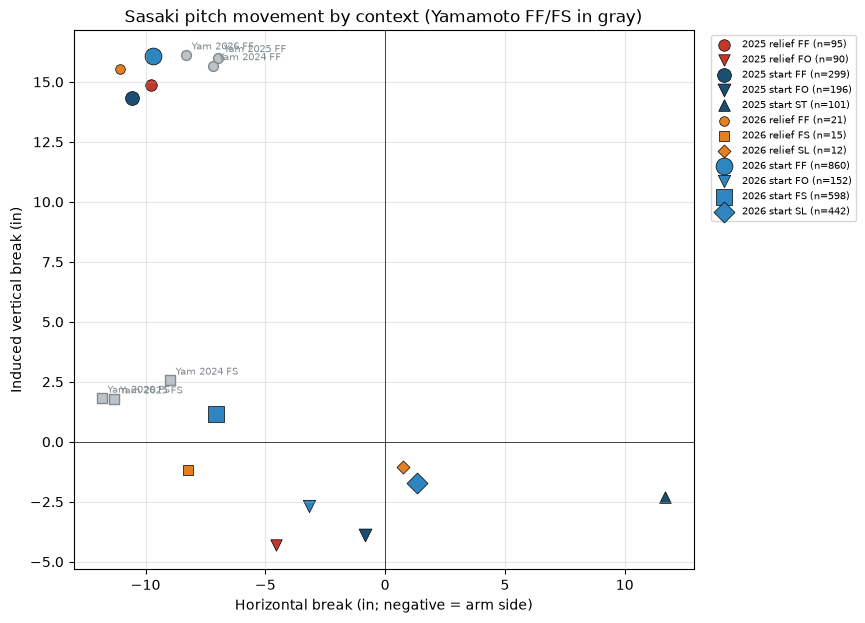

In [11]:
COLORS = {"2025 start": "#1b4f72", "2025 relief": "#c0392b", "2026 start": "#2e86c1", "2026 relief": "#e67e22"}
MARK = {"FF": "o", "FO": "v", "FS": "s", "ST": "^", "SL": "D"}
fig, ax = plt.subplots(figsize=(8, 7))
for (c, pt), d in sas[sas.pitch_type.isin(MARK)].groupby(["context", "pitch_type"]):
    ax.scatter(d.hb.mean(), d.ivb.mean(), s=30 + 4 * np.sqrt(len(d)), marker=MARK[pt], color=COLORS[c],
               edgecolor="black", lw=0.5, label=f"{c} {pt} (n={len(d)})")
for (s, pt), d in yam[yam.pitch_type.isin(["FF", "FS"])].groupby(["season", "pitch_type"]):
    ax.scatter(d.hb.mean(), d.ivb.mean(), s=50, marker=MARK[pt], color="#bdc3c7", edgecolor="#7f8c8d")
    ax.annotate(f"Yam {s} {pt}", (d.hb.mean(), d.ivb.mean()), fontsize=7, color="#7f8c8d", xytext=(4, 4), textcoords="offset points")
ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Horizontal break (in; negative = arm side)")
ax.set_ylabel("Induced vertical break (in)")
ax.set_title("Sasaki pitch movement by context (Yamamoto FF/FS in gray)")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.grid(alpha=0.3)
fig.savefig(FIG / "s1_movement.png", dpi=150, bbox_inches="tight")

## Figure 2 — Velocity timeline per appearance

/Users/Kylan/Desktop/MonsterAdjustment/.venv/lib/python3.13/site-packages/pyarrow/compute.py:230: FutureWarning: Specifying null_placement in RankOptions is deprecated as of 25.0.0. Specify null_placement per sort_key instead.
  return options_class(*args, **kwargs)


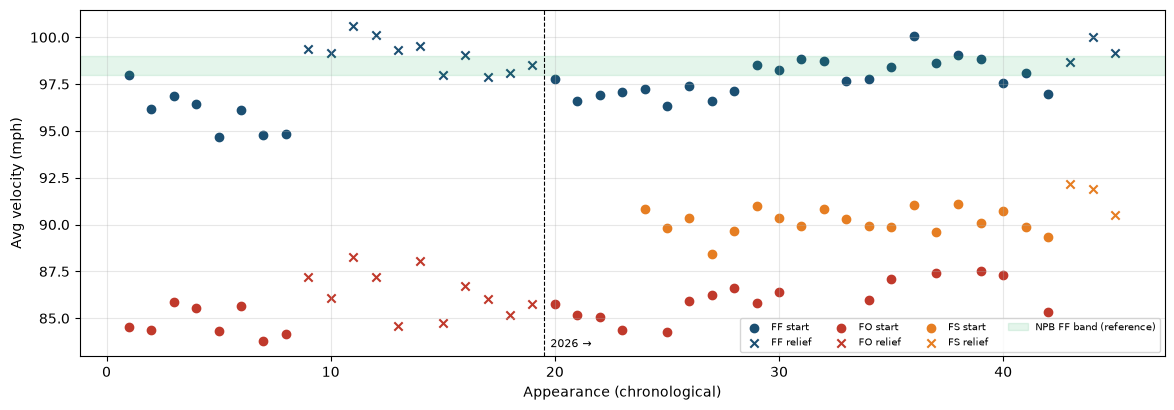

In [12]:
fig, ax = plt.subplots(figsize=(14, 4.5))
per_game = sas[sas.pitch_type.isin(["FF", "FO", "FS"])].groupby(["game_date", "game_pk", "role", "pitch_type"]).release_speed.mean().reset_index()
per_game["game_date"] = pd.to_datetime(per_game.game_date)
per_game["x"] = per_game.game_date.dt.strftime("%Y-%m-%d").rank(method="dense")
for pt, color in [("FF", "#1b4f72"), ("FO", "#c0392b"), ("FS", "#e67e22")]:
    for role, marker in [("start", "o"), ("relief", "x")]:
        d = per_game[(per_game.pitch_type == pt) & (per_game.role == role)]
        ax.scatter(d.x, d.release_speed, color=color, marker=marker, label=f"{pt} {role}")
ax.axhspan(98, 99, color="#27ae60", alpha=0.12, label="NPB FF band (reference)")
split = per_game[per_game.game_date.dt.year == 2026].x.min() - 0.5
ax.axvline(split, color="black", ls="--", lw=0.8)
ax.text(split + 0.3, ax.get_ylim()[0] + 0.5, "2026 →", fontsize=8)
ax.set_xlabel("Appearance (chronological)")
ax.set_ylabel("Avg velocity (mph)")
ax.legend(fontsize=7, ncol=4)
ax.grid(alpha=0.3)
fig.savefig(FIG / "s1_velocity_timeline.png", dpi=150, bbox_inches="tight")

## Figure 3 — Delivery by context (FF)

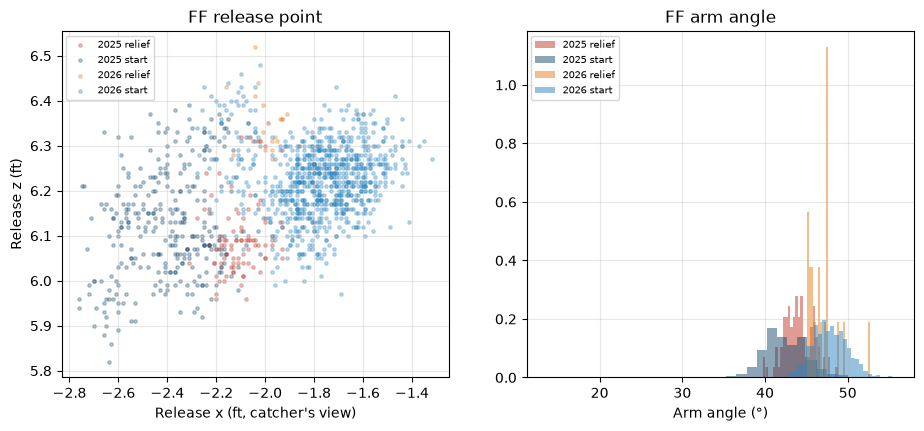

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for c, d in ff[ff.pitcher_name == "sasaki"].groupby("context"):
    axes[0].scatter(d.release_pos_x, d.release_pos_z, s=6, alpha=0.3, color=COLORS[c], label=c)
    axes[1].hist(d.arm_angle.dropna(), bins=30, alpha=0.5, color=COLORS[c], label=c, density=True)
axes[0].set_xlabel("Release x (ft, catcher's view)")
axes[0].set_ylabel("Release z (ft)")
axes[0].set_title("FF release point")
axes[1].set_xlabel("Arm angle (°)")
axes[1].set_title("FF arm angle")
for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
fig.savefig(FIG / "s1_delivery.png", dpi=150, bbox_inches="tight")